## Objective:

The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms


# Exploratory Data Analysis (EDA):

**1. Load the dataset using Python's pandas library.**

**2. Check for missing values.**

**3. Explore data distributions using histograms and box plots.**

**4. Visualize relationships between features and survival using scatter plots and bar plots.**


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset/diabetes (1).csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Glucose has minimum = 0

BloodPressure has minimum = 0

SkinThickness has minimum = 0

Insulin has minimum = 0

BMI has minimum = 0

Medically, these cannot be zero → So 0 represents missing values.

In [6]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

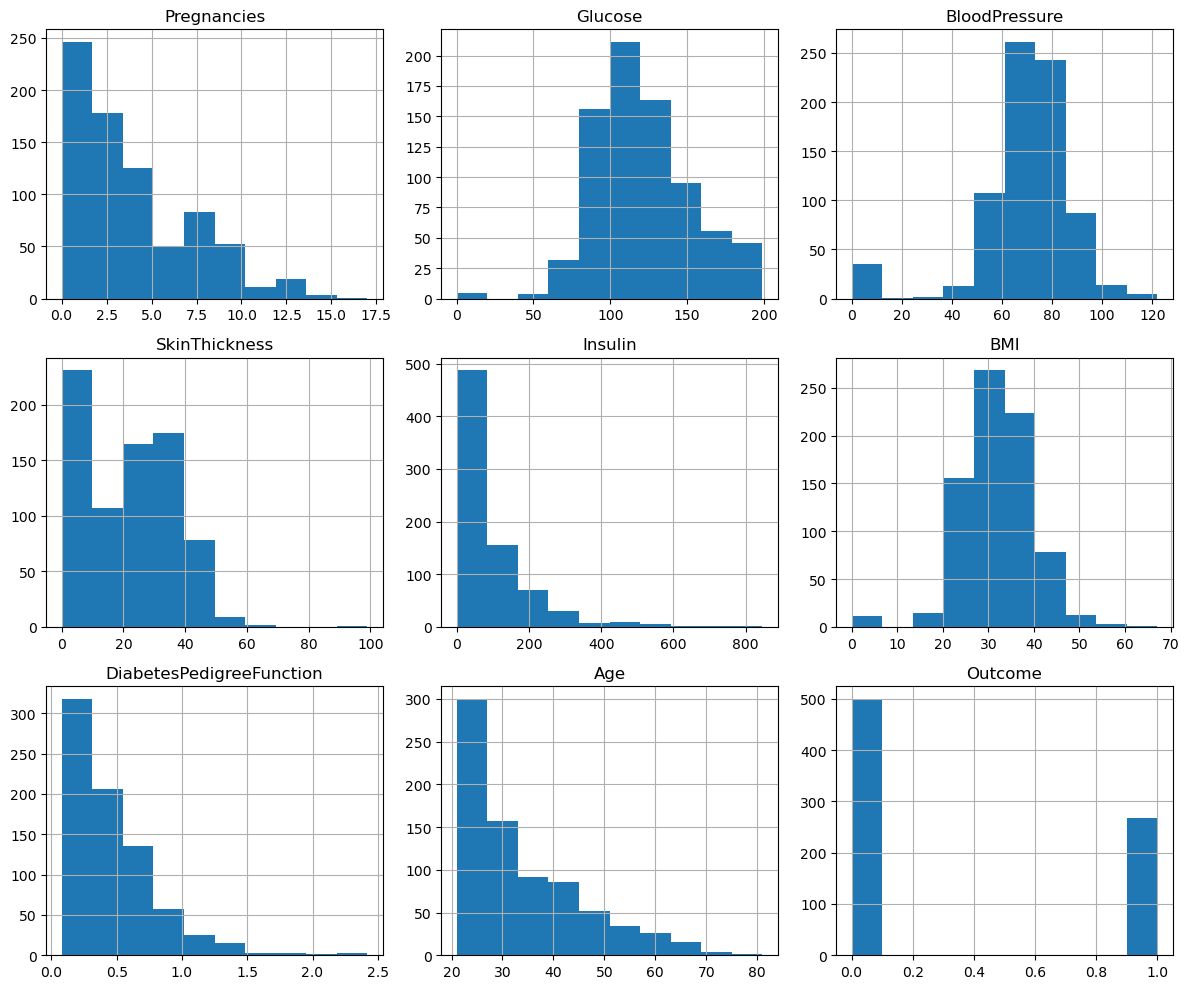

In [7]:
# Histogram

df.hist(figsize=(12,10), bins=10)
plt.tight_layout()
plt.show()

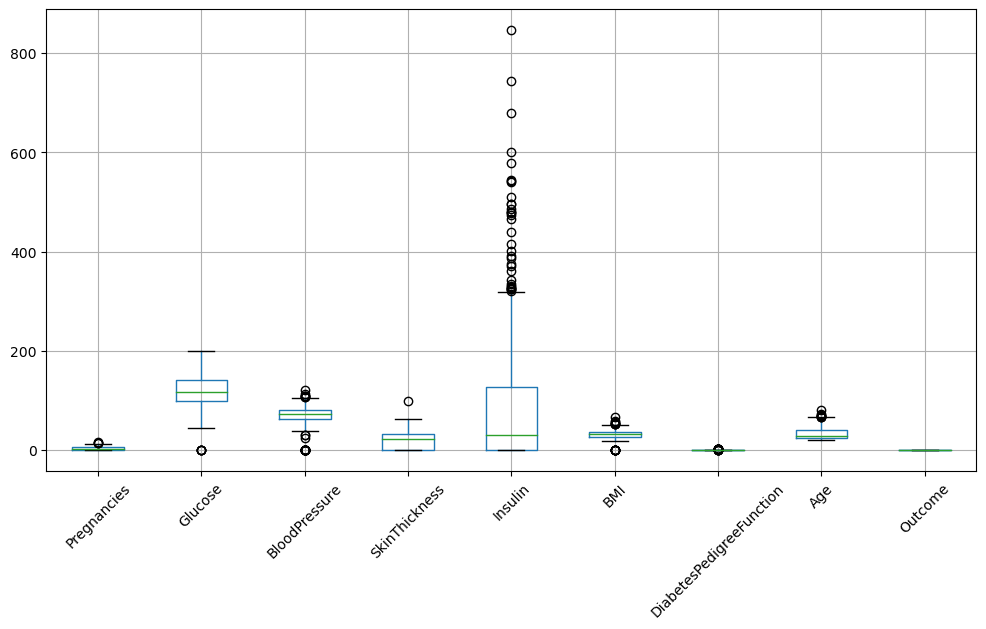

In [8]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

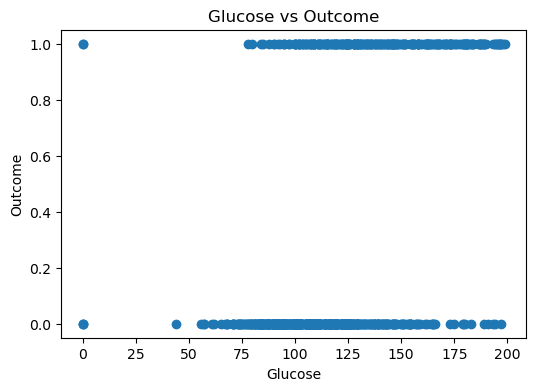

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(df["Glucose"], df["Outcome"])
plt.xlabel("Glucose")
plt.ylabel("Outcome")
plt.title("Glucose vs Outcome")
plt.show()

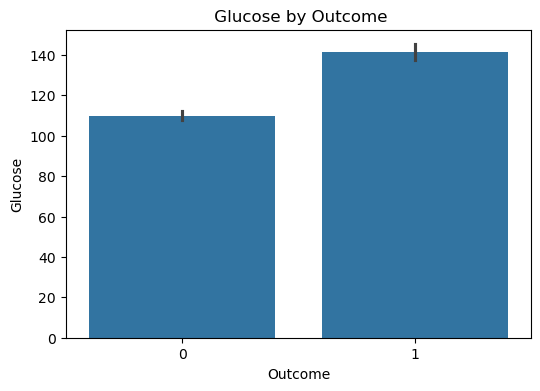

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(x="Outcome", y="Glucose", data=df)
plt.title(" Glucose by Outcome")
plt.show()

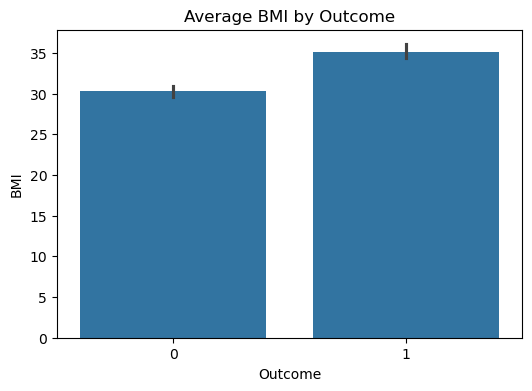

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(x="Outcome", y="BMI", data=df)
plt.title("Average BMI by Outcome")
plt.show()

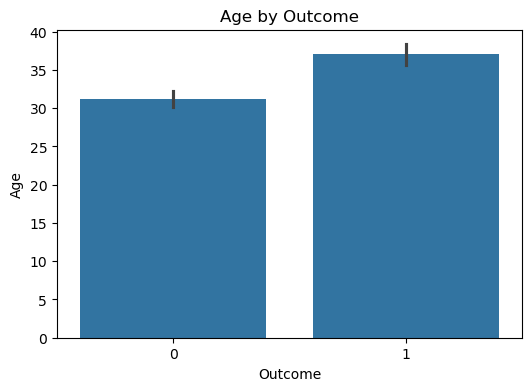

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(x="Outcome", y="Age", data=df)
plt.title("Age by Outcome")
plt.show()

The dataset contains 768 records with 8 numerical predictor variables and one binary target variable (Outcome). No missing values were observed in the dataset; however, certain medical features contain zero values that may represent missing data. Histograms reveal skewness in features such as Insulin and Age, while BMI and Glucose show moderate spread. Box plots indicate the presence of outliers, particularly in Insulin and BMI. Scatter and bar plots demonstrate that Glucose, BMI, and Age exhibit noticeable differences between diabetic and non-diabetic groups

## Data Preprocessing:

**1. Impute missing values.**

**2. Encode categorical variables using one-hot encoding or label encoding.**

**3. If needed you can apply more preprocessing methods on the given dataset.**


In [13]:
cols = ['Glucose', 'BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0,np.nan)

In [14]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [15]:
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

In [16]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Although no null values were initially detected, certain medical variables contained zero values that are not biologically possible. These were treated as missing values and replaced with NaN. Median imputation was applied to handle skewed distributions and minimize the effect of outliers.

In [17]:
df.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

The dataset contains only numerical features and a binary target variable. Therefore, no categorical encoding techniques such as One-Hot Encoding or Label Encoding were required.

## Building Predictive Models:

**1.	Split the preprocessed dataset into training and testing sets.**

**2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.**

**3.	Build predictive models using LightGBM and XGBoost algorithms.**

**4.	Train the models on the training set and evaluate their performance on the testing set.**

**5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.**


In [43]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis =1)
y =df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print('Training Shape: ',X_train.shape)
print('Testing shape: ',X_test.shape)

Training Shape:  (537, 8)
Testing shape:  (231, 8)


The preprocessed dataset was divided into training and testing sets using an 70-30 split with stratified sampling to maintain class balance. The training set contained 537 samples, while the testing set contained 231 samples, ensuring sufficient data for both model training and performance evaluation.

In [23]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1,
                         max_depth=3, random_state=42,
                         eval_metric ='logloss')

xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [24]:
# Prediction

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [25]:
# Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("XGBoost Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb),3))
print("Precision:", round(precision_score(y_test, y_pred_xgb),3))
print("Recall:", round(recall_score(y_test, y_pred_xgb),3))
print("F1 Score:", round(f1_score(y_test, y_pred_xgb),3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb),3))

XGBoost Results:
Accuracy: 0.762
Precision: 0.703
Recall: 0.556
F1 Score: 0.621
ROC-AUC: 0.835


These results indicate that XGBoost performs well in overall classification accuracy and has strong discriminative capability (ROC-AUC 0.835).

In [29]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=-1, random_state=42)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 187, number of negative: 350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 611
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348231 -> initscore=-0.626825
[LightGBM] [Info] Start training from score -0.626825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(random_state=42)

In [30]:
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]

In [31]:
print("LightGBM Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lgbm),3))
print("Precision:", round(precision_score(y_test, y_pred_lgbm),3))
print("Recall:", round(recall_score(y_test, y_pred_lgbm),3))
print("F1 Score:", round(f1_score(y_test, y_pred_lgbm),3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lgbm),3))

LightGBM Results:
Accuracy: 0.727
Precision: 0.625
Recall: 0.556
F1 Score: 0.588
ROC-AUC: 0.822


LightGBM showed slightly lower accuracy and F1-score compared to XGBoost, though recall remained the same. The ROC-AUC score of 0.822 indicates good classification capability but slightly lower than XGBoost.

In [33]:
# Cross-Validation

from sklearn.model_selection import cross_val_score

cv_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
cv_lgbm = cross_val_score(lgbm_model, X, y, cv=5, scoring='accuracy')


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [34]:
print("XGB CV Accuracy:", round(cv_xgb.mean(),3))
print("LGBM CV Accuracy:", round(cv_lgbm.mean(),3))

XGB CV Accuracy: 0.759
LGBM CV Accuracy: 0.753


XGB Cross-validation yielded an average accuracy of 75.9%, confirming stable model performance across folds.

LGBM Cross-validation accuracy was 75.3%, indicating consistent performance across folds.

In [37]:
# XGBoost Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3,5,7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss'),
                        param_grid_xgb,
                        cv=3,
                        scoring='accuracy',
                        n_jobs=-1)

grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1]},
             scoring='accuracy')

In [38]:
print("Best XGB Params:", grid_xgb.best_params_)
print('Best XGB Score:',grid_xgb.best_score_)

Best XGB Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best XGB Score: 0.7523277467411545


In [39]:
# LightGBM Hyperparameter Tuning

param_grid_lgbm = {
    'n_estimators': [100,200],
    'learning_rate': [0.01,0.1],
    'num_leaves': [31,50],
    'max_depth': [-1,5,10]
}

grid_lgbm = GridSearchCV(LGBMClassifier(),
                         param_grid_lgbm,
                         cv=3,
                         scoring='accuracy',
                         n_jobs=-1)

grid_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 187, number of negative: 350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 611
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348231 -> initscore=-0.626825
[LightGBM] [Info] Start training from score -0.626825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

GridSearchCV(cv=3, estimator=LGBMClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [-1, 5, 10],
                         'n_estimators': [100, 200], 'num_leaves': [31, 50]},
             scoring='accuracy')

In [40]:
print("Best LGBM Params:", grid_lgbm.best_params_)
print('Best LGBM Score:',grid_lgbm.best_score_)

Best LGBM Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
Best LGBM Score: 0.7635009310986964


Both gradient boosting algorithms performed well on the diabetes dataset. However, XGBoost slightly outperformed LightGBM in terms of test accuracy and ROC-AUC, indicating better generalization and discriminative ability.

## Comparative Analysis:

**1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.**

The performance of XGBoost and LightGBM was evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

From the comparison:

* XGBoost achieved higher accuracy (76.2%) compared to LightGBM (72.7%).

* XGBoost also showed better precision, meaning it made fewer false positive predictions.

* Both models had the same recall (0.556), indicating similar ability to detect diabetic cases.

* XGBoost had a higher F1-score and ROC-AUC, suggesting better overall balance and discriminative performance.

* Although LightGBM performed competitively, XGBoost demonstrated slightly stronger predictive capability on the test dataset.

**2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.**


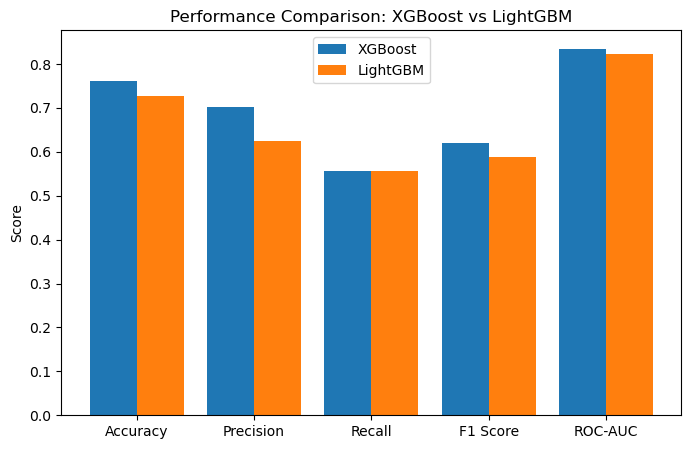

In [44]:
metrics = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']

xgb_scores = [0.762,0.703,0.556,0.621,0.835]
lgbm_scores = [0.727,0.625,0.556,0.588,0.822]

x = np.arange(len(metrics))

plt.figure(figsize=(8,5))
plt.bar(x-0.2, xgb_scores, width=0.4, label='XGBoost')
plt.bar(x+0.2, lgbm_scores, width=0.4, label='LightGBM')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison: XGBoost vs LightGBM")
plt.legend()
plt.show()

* The visualization clearly shows XGBoost outperforming LightGBM in most evaluation metrics.

* LightGBM performed competitively but slightly lower in precision and F1-score.

* Both models show moderate recall, indicating potential difficulty in identifying all positive diabetic cases.

* The higher ROC-AUC for XGBoost suggests stronger capability in distinguishing between diabetic and non-diabetic patients across thresholds.

## Strengths & Weaknesses:

**XGBoost Strengths**

* Higher predictive accuracy

* Better precision and F1-score

* Strong discriminative power (ROC-AUC)

**XGBoost Weakness**

* Slightly more computationally intensive

**LightGBM Strengths**

* Faster training (especially for large datasets)

* Competitive cross-validation performance

**LightGBM Weakness**

* Slightly lower predictive performance on test data